# Face Recognition with PCA (Eigenfaces)

This notebook builds a small **face recognition system** on top of **Principal Component Analysis (PCA)**, also known as the *eigenfaces* method.

**What it does**

1. Loads a dataset of 50×50 grayscale face images (10 people, 64 images each, split into 5 sets with increasingly difficult lighting conditions).
2. Pre-processes the images (histogram equalization, gamma correction, per-image standardization).
3. Learns a low-dimensional face space with PCA, using only the images of **Set 1** for training.
4. Measures how well faces from every set are recognized with a **nearest-neighbor classifier** in that space, for different numbers of principal components.
5. Compares PCA (eigen-decomposition of the covariance matrix) with the **SVD** of the data matrix.

**Contents**

| Task | Topic |
|------|-------|
| 2.1 | Data loading and pre-processing |
| 2.2 | PCA projection and reconstruction of a face |
| 2.3 | Reconstruction error vs. number of principal components |
| 2.4 | Visualizing the eigenfaces |
| 2.5 | Face recognition accuracy on every set |
| 2.6 | Reconstruction of faces from every set |
| 2.7 | Comparison with SVD |

**Requirements:** `numpy`, `matplotlib`, `opencv-python`, `scikit-learn`, and the dataset archive `faces.zip` placed next to this notebook (images named `personXX_YY.png`).

##Setup

In [18]:
import os
import random
from zipfile import ZipFile

import cv2
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

Given `faces.zip`, extract the images into the `faces` folder.

In [19]:
# Extract the images from faces.zip into the ./faces folder.
with ZipFile('faces.zip', 'r') as zip_ref:
    zip_ref.extractall('faces')

## Task 1: Loading and pre-processing the images

The images of **Sets 3, 4 and 5** are darker and contain strong shadows. In addition to the suggested pre-processing, I chose to apply two extra steps to improve recognition accuracy on these sets:

- **Gamma correction** with a value γ < 1, which brightens the images. A different γ is used for each set: the darker the set, the smaller the γ.
- **Histogram equalization**, which improves the contrast of the images. This is useful when the intensities are low and concentrated in a narrow range, as happens with the shadows in our sets.

In [20]:
# Image numbers (1-64) that belong to each set. Every person has 64 images in total.
ImageSet_D = {
    "Set1": range(1, 8),
    "Set2": range(8, 20),
    "Set3": range(20, 32),
    "Set4": range(32, 46),
    "Set5": range(46, 65),
}

# Gamma value used for each set (in the order Set1 ... Set5).
# None = no correction; the smaller the value, the brighter the result.
gammaPerSet = [None, 0.9, 0.7, 0.3, 0.2]


def load_images(path, setNumber, gamma=None, hist_eq=True):
    """Load all images of one set for the 10 people.

    Parameters
    ----------
    path : str
        Folder that contains the extracted images.
    setNumber : str
        Name of the set to load, e.g. "Set1".
    gamma : float or None
        If given, gamma correction (pixel ** gamma) is applied.
    hist_eq : bool
        If True, histogram equalization is applied to every image.

    Returns
    -------
    X : ndarray of shape (2500, n_images)
        Every column is one flattened 50x50 image with values in [0, 1].
    y : ndarray of shape (n_images,)
        Person label of each image (0 for person01, 1 for person02, ...).
    """
    if setNumber not in ImageSet_D:      # Valid set check.
        raise ValueError("Invalid set number")

    iSet = ImageSet_D[setNumber]

    ImagesData = []
    label = []

    for personN in range(1, 11):     # For every person...
        for imageN in iSet:          # ...and every image of the set.

            imageFile = f"person{personN:02d}_{imageN:02d}.png"   # Build the image file name.
            imagePath = os.path.join(path, imageFile)

            image = cv2.imread(imagePath, cv2.IMREAD_GRAYSCALE)   # Load as grayscale.

            if image is None or image.shape != (50, 50):
                raise ValueError(f"Invalid image: {imagePath}")

            if hist_eq:                                    # Histogram equalization (on 8-bit values).
                image = cv2.equalizeHist(image)

            image = image.astype(np.float32) / 255.0       # Normalize the values to [0, 1].

            if gamma is not None:                          # Gamma correction (gamma < 1 brightens).
                image = np.power(image, gamma)

            image = image.flatten()        # Convert from 50x50 to a vector of 2500 values.
            ImagesData.append(image)       # Add the image to the list.
            label.append(personN - 1)      # Label: 0 for person01, 1 for person02, etc.

    X = np.array(ImagesData).T    # One image per column: shape (2500, n_images).
    y = np.array(label)

    return X, y

## Task 2: PCA projection and reconstruction

We train PCA on the 70 images of Set 1 (7 images for each of the 10 people), reduce every face to **d = 30** dimensions, and then reconstruct a randomly chosen face from those 30 values.

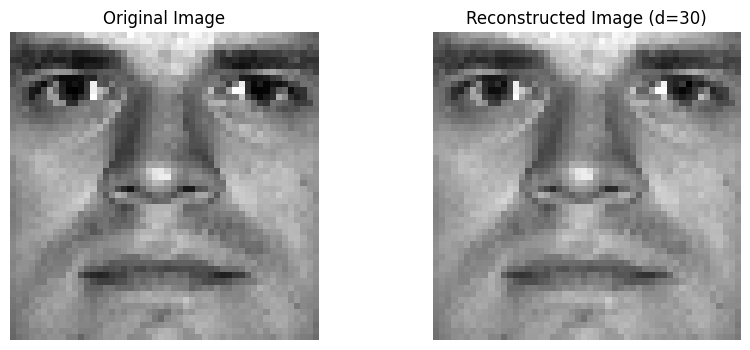

In [31]:
X, y = load_images("./faces/faces", "Set1", gammaPerSet[0], hist_eq=False)   # Load all images of Set 1.

# Standardize each image: subtract its own mean and divide by its own standard deviation.
means = np.mean(X, axis=0, keepdims=True)           # Mean value of each column (image).
stdDeviations = np.std(X, axis=0, keepdims=True)    # Standard deviation of each column (image).
stdDeviations[stdDeviations == 0] = 1               # Avoid division by zero.

X_norm = (X - means) / stdDeviations


d = 30   # Reduce the dimensionality from 2500 to 30.
pca = PCA(n_components=d)
pca.fit(X_norm.T)          # scikit-learn expects one sample per row, hence the transpose.


randImageN = random.randint(0, X.shape[1] - 1)          # Pick a random image of the dataset.
image = X_norm[:, randImageN].reshape(1, -1)

projected = pca.transform(image)                  # Project to 30 dimensions.
reconstructed = pca.inverse_transform(projected)  # Reconstruct back to 2500 dimensions.


plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)        # Original image
plt.imshow(X[:, randImageN].reshape(50, 50), cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)        # Reconstructed image
plt.imshow(reconstructed.reshape(50, 50), cmap='gray')
plt.title(f"Reconstructed Image (d={d})")
plt.axis("off")

plt.show()

**Observations**

The reconstructed image is not very different from the original, and the two faces clearly look alike. The differences show up in the fine details: the reconstruction is dominated by values close to the mean brightness (sharp changes in intensity are lost), so the "new" image is blurrier than the original.

## Task 2.3: Reconstruction error vs. number of principal components

scikit-learn's `PCA` cannot use more components than the number of images (70 here). To test larger values of d, we implement PCA ourselves through the **eigen-decomposition of the covariance matrix**.

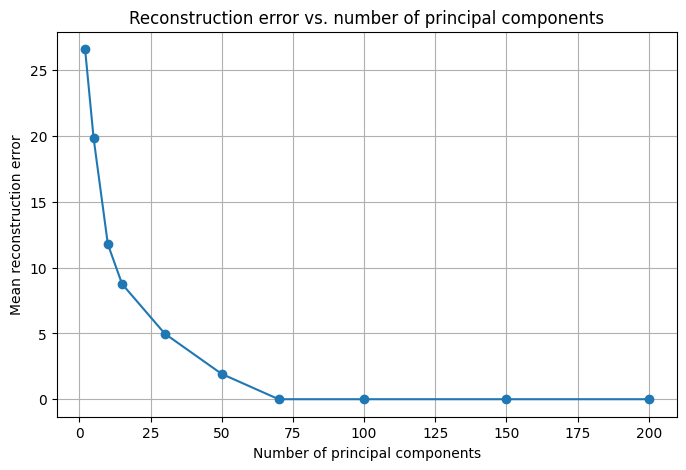

In [32]:
dimensions = [2, 5, 10, 15, 30, 50, 70, 100, 150, 200]   # Numbers of principal components to test.
errors = []

# Center every pixel (row) across the images.
X_centered = X_norm - np.mean(X_norm, axis=1, keepdims=True)
covMatrix = np.cov(X_centered)     # 2500 x 2500 covariance matrix of the pixels.

# The covariance matrix is symmetric, so eigh() is appropriate (eigenvalues in ascending order).
eigvalues, eigvectors = np.linalg.eigh(covMatrix)

# Build (eigenvalue, eigenvector) pairs and sort them by decreasing eigenvalue.
eig_pairs = [(val, eigvectors[:, i]) for i, val in enumerate(eigvalues)]
eig_pairs.sort(key=lambda x: x[0], reverse=True)


for d in dimensions:
    top_eigvectors = [vec.reshape(-1, 1) for (val, vec) in eig_pairs[:d]]  # Keep the top-d eigenvectors.
    w = np.hstack(top_eigvectors)                                          # Projection matrix (2500 x d).

    Z = w.T @ X_centered         # Project the 70 images onto d dimensions.

    X_reconstructed = w @ Z      # Reconstruct the images from the d-dimensional representation.
    X_reconstructed += np.mean(X_norm, axis=1, keepdims=True)    # Add the mean back.

    # Reconstruction error: mean Euclidean distance between original and reconstructed images.
    error = np.mean(np.linalg.norm(X_norm - X_reconstructed, axis=0))
    errors.append(error)


plt.figure(figsize=(8, 5))

plt.plot(dimensions, errors, marker='o')
plt.xlabel("Number of principal components")
plt.ylabel("Mean reconstruction error")
plt.title("Reconstruction error vs. number of principal components")
plt.grid(True)
plt.show()

**Observations**

The error decreases as the number of components grows. For small values of d the reconstruction error is large, but each additional component initially brings a big drop in the error.

With 50-70 principal components the error is already much smaller, and it keeps decreasing at a slow rate as d increases.

With 70 or more components, i.e. as many as the number of images, the error becomes zero, because we keep all the information that was in the data. The image matrix has at most 70 linearly independent vectors, so 70 components are enough to describe it completely.

## Task 2.4: Visualizing the eigenfaces

The eigenvectors of the covariance matrix, reshaped back to 50×50 images, are called **eigenfaces**. Here are the 9 with the largest eigenvalues.

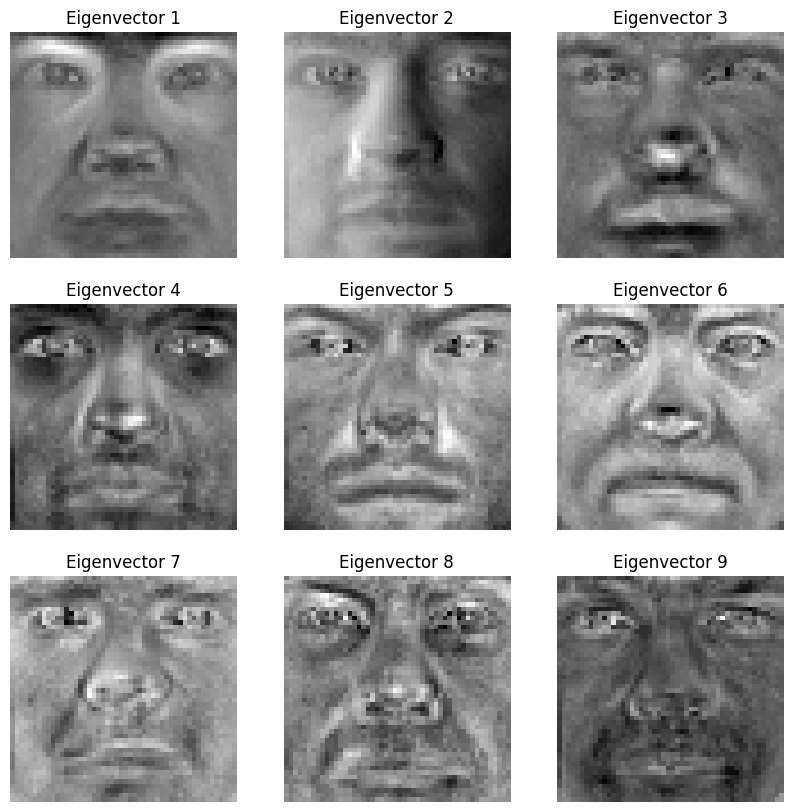

In [34]:
top9 = [vec.reshape(50, 50) for (val, vec) in eig_pairs[:9]]   # The 9 eigenvectors with the largest eigenvalues.


plt.figure(figsize=(10, 10))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(top9[i], cmap='gray')
    plt.title(f"Eigenvector {i+1}")
    plt.axis('off')

plt.show()

**Observations**

The first 3 eigenvectors capture the general shape of an average face in the dataset.

The following eigenvectors show finer details and variations on top of that basic face. They differ in brightness, in the shape of the mouth and nose, and in the shape of the face.

The eigenvectors express the main directions of variation among the faces, each one describing a characteristic pattern of variation. As a result, a linear combination of the eigenvectors can reconstruct any face with the best possible accuracy for the chosen number of components.

## Task 2.5: Face recognition accuracy

The recognition procedure is:

1. **Train:** project the 70 images of Set 1 onto the first d eigenvectors.
2. **Test:** project every image of the set under test onto the same d eigenvectors.
3. **Classify:** assign to each test image the label of the *nearest* training image in the projected space (1-nearest-neighbor with Euclidean distance).
4. Repeat for every set and every d, and record the percentage of correctly recognized faces.


=== Recognition Results ===

Results for Set1:
  d=  2 -> Accuracy: 100.00%
  d=  5 -> Accuracy: 90.00%
  d= 10 -> Accuracy: 100.00%
  d= 15 -> Accuracy: 100.00%
  d= 30 -> Accuracy: 100.00%
  d= 50 -> Accuracy: 100.00%
  d= 70 -> Accuracy: 100.00%
  d=100 -> Accuracy: 100.00%
  d=150 -> Accuracy: 100.00%
  d=200 -> Accuracy: 100.00%
----------------------------------------
Results for Set2:
  d=  2 -> Accuracy: 44.17%
  d=  5 -> Accuracy: 78.33%
  d= 10 -> Accuracy: 100.00%
  d= 15 -> Accuracy: 100.00%
  d= 30 -> Accuracy: 100.00%
  d= 50 -> Accuracy: 100.00%
  d= 70 -> Accuracy: 100.00%
  d=100 -> Accuracy: 100.00%
  d=150 -> Accuracy: 100.00%
  d=200 -> Accuracy: 100.00%
----------------------------------------
Results for Set3:
  d=  2 -> Accuracy: 16.67%
  d=  5 -> Accuracy: 48.33%
  d= 10 -> Accuracy: 77.50%
  d= 15 -> Accuracy: 90.83%
  d= 30 -> Accuracy: 93.33%
  d= 50 -> Accuracy: 93.33%
  d= 70 -> Accuracy: 93.33%
  d=100 -> Accuracy: 93.33%
  d=150 -> Accuracy: 93.33%
  d=2

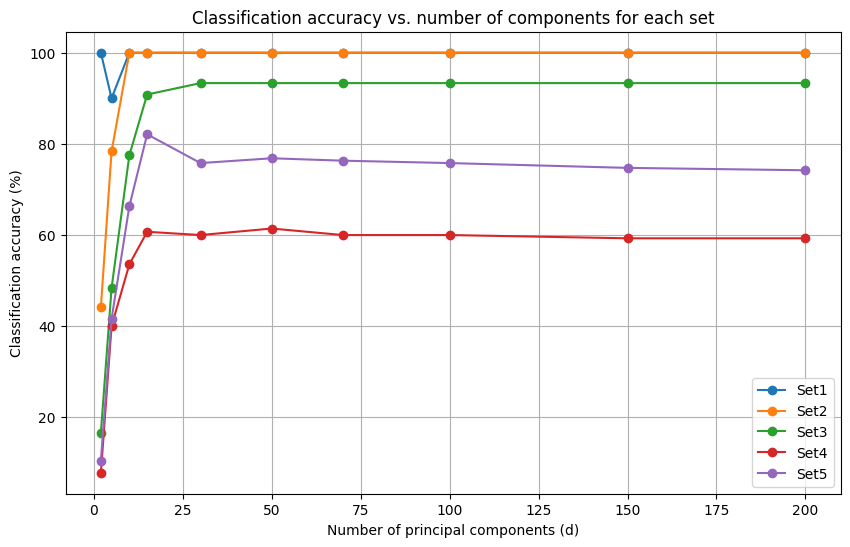

In [36]:
# Training data: Set 1 (the same set that was used to compute the eigenvectors).
X_train, y_train = load_images("./faces/faces", "Set1", gammaPerSet[0])
X_train_centered = X_train - np.mean(X_train, axis=1, keepdims=True)


setsAccuracy_D = {setName: [] for setName in ImageSet_D}   # For each set: a list with one accuracy per value of d.


for i, setName in enumerate(ImageSet_D):

    # Load all images of the set, using the gamma value chosen for that set.
    x_data, y_label = load_images("./faces/faces", setName, gammaPerSet[i])
    X_data_centered = x_data - np.mean(x_data, axis=0, keepdims=True)   # Center the test images.

    accuracies = []

    for d in dimensions:
        top_eigvectors = [vec.reshape(-1, 1) for (val, vec) in eig_pairs[:d]]  # Keep the top-d eigenvectors.
        w = np.hstack(top_eigvectors)

        Z_train = w.T @ X_train_centered       # Project the training images to d dimensions.
        Z_test = w.T @ X_data_centered         # Project the test images to d dimensions.


        correctPredictions = 0                # Counter of correct predictions.
        samplesNumber = x_data.shape[1]       # Total number of images in the set.

        for imageId in range(samplesNumber):
            image = Z_test[:, imageId]        # Projection of this test image in d dimensions.

            # Euclidean distance to every training image; the closest one gives the prediction.
            distances = np.linalg.norm(Z_train.T - image, axis=1)
            nearest_neighbor = np.argmin(distances)

            true_label = y_label[imageId]
            predicted_label = y_train[nearest_neighbor]

            if true_label == predicted_label:
                correctPredictions += 1

        accuracy = (correctPredictions / samplesNumber) * 100     # Accuracy as a percentage.
        accuracies.append(accuracy)

    setsAccuracy_D[setName] = accuracies       # Store the results of this set.



# Print the results.
print("\n=== Recognition Results ===\n")
for setName in setsAccuracy_D:
    print(f"Results for {setName}:")
    for d, accuracy in zip(dimensions, setsAccuracy_D[setName]):
        print(f"  d={d:3d} -> Accuracy: {accuracy:.2f}%")
    print("-" * 40)


# Plot accuracy against the number of components, one line per set.
plt.figure(figsize=(10, 6))

for setName in setsAccuracy_D:
    accuracies = setsAccuracy_D[setName]
    plt.plot(dimensions, accuracies, marker='o', label=setName)

plt.xlabel("Number of principal components (d)")
plt.ylabel("Classification accuracy (%)")
plt.title("Classification accuracy vs. number of components for each set")
plt.legend()
plt.grid(True)
plt.show()

**Observations**

**a) Accuracy per set**

- **Set 2** reaches the maximum accuracy (100%) for every d of 10 or more.
- **Set 1** (the training set itself) also reaches 100% with few components (10 and above).
- **Sets 3, 4 and 5** have noticeably lower accuracy. In Set 3, accuracy improves considerably as d grows and reaches about 93% for d = 30. In Set 4 accuracy levels off at around 60%, and in Set 5 it peaks at about 82% (d = 15) and then settles around 75%.

The images in Sets 3, 4 and 5 have much lower illumination and different shadows, so a model trained only on Set 1 cannot separate the faces correctly.

**b) Stability**

For d = 30 or d = 50 the accuracy becomes stable across the 5 sets. For d > 50 it does not improve significantly.

**c) Chosen value of d**

I would choose **d = 30** for the model, since it reaches approximately the best achievable accuracy for every set while keeping the complexity low.

## Task 2.6: Reconstruction of faces from every set

For each set, a random face is projected onto the 30 components learned from Set 1 and then reconstructed. This shows how well the "face space" learned from Set 1 represents faces taken under different lighting conditions.

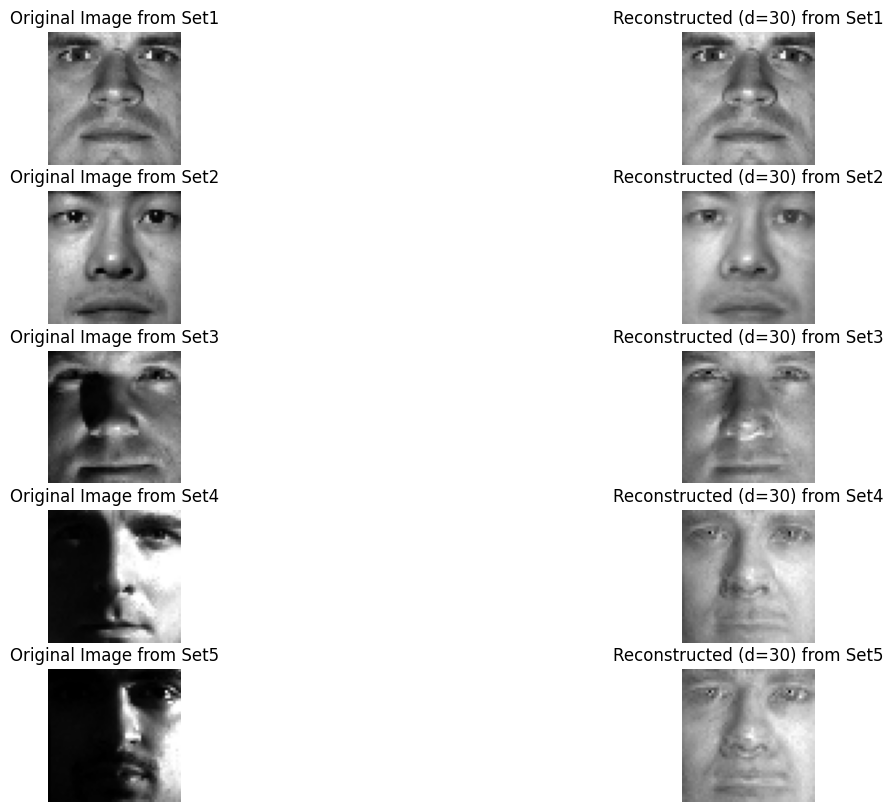

In [37]:
d = 30     # Selected number of components (see Task 2.5).

top_eigvectors = [vec.reshape(-1, 1) for (val, vec) in eig_pairs[:d]]  # Keep the top-d eigenvectors.
w = np.hstack(top_eigvectors)

plt.figure(figsize=(15, 10))

i = 0
for setName in ImageSet_D:
    X_data, y_data = load_images("./faces/faces", setName, hist_eq=False)

    # Standardize each image, exactly as during training.
    means = np.mean(X_data, axis=0, keepdims=True)           # Mean value of each image.
    stdDeviations = np.std(X_data, axis=0, keepdims=True)    # Standard deviation of each image.
    stdDeviations[stdDeviations == 0] = 1                    # Avoid division by zero.

    X_norm = (X_data - means) / stdDeviations

    randImageNumber = random.randint(0, X_data.shape[1] - 1)    # Pick a random image of the set.
    image = X_norm[:, randImageNumber].reshape(1, -1)

    projected = pca.transform(image)                  # Project to 30 dimensions (PCA trained on Set 1).
    reconstructed = pca.inverse_transform(projected)  # Reconstruct back to 2500 dimensions.

    # Original image
    plt.subplot(5, 2, 2*i + 1)
    plt.imshow(X_data[:, randImageNumber].reshape(50, 50), cmap='gray')
    plt.title(f"Original Image from {setName}")
    plt.axis('off')

    # Reconstructed image
    plt.subplot(5, 2, 2*i + 2)
    plt.imshow(reconstructed.reshape(50, 50), cmap='gray')
    plt.title(f"Reconstructed (d={d}) from {setName}")
    plt.axis('off')

    i += 1   # Row counter used for the subplot positions.


plt.show()

**Observations**

The reconstructed images from Set 1 and Set 2 are very close to the originals, since PCA was trained on similar data.

In Sets 3, 4 and 5, on the other hand, the reconstruction quality gradually degrades because of the different lighting conditions and shadows, which the model never "saw" during training. PCA therefore cannot represent those images satisfactorily.

## Task 2.7: Comparison with SVD

PCA can also be computed through the **Singular Value Decomposition (SVD)** of the data matrix. Here we plot the leading left singular vectors of the standardized Set 1 matrix and compare them with the eigenfaces from Task 2.4.

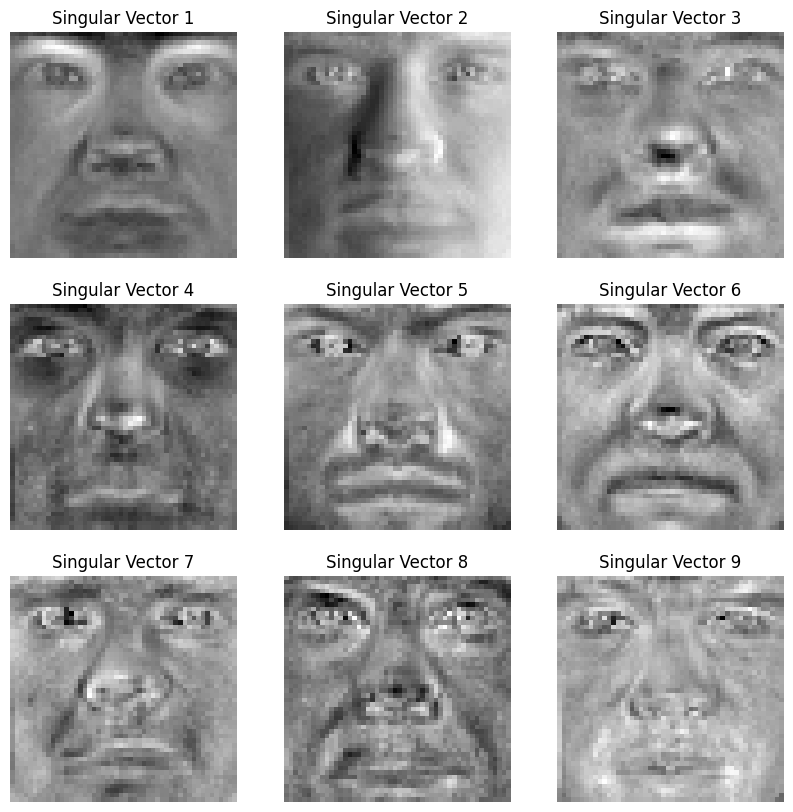

In [38]:
X, y = load_images("./faces/faces", "Set1", gammaPerSet[0], hist_eq=False)   # Load all images of Set 1.

# Standardize each image (same pre-processing as before).
means = np.mean(X, axis=0, keepdims=True)           # Mean value of each column (image).
stdDeviations = np.std(X, axis=0, keepdims=True)    # Standard deviation of each column (image).
stdDeviations[stdDeviations == 0] = 1               # Avoid division by zero.

X_norm = (X - means) / stdDeviations


# SVD of the data matrix: the columns of U are the left singular vectors (2500-dimensional "faces").
U, s, VT = np.linalg.svd(X_norm)

# The data matrix was not centered across images, so the first singular vector mostly encodes
# the mean face. It is skipped, and the next 9 vectors are shown for comparison with the eigenfaces.
top9_singularVectors = [U[:, i].reshape(50, 50) for i in range(10)]


plt.figure(figsize=(10, 10))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(top9_singularVectors[i+1], cmap='gray')    # i+1 skips the mean-face component.
    plt.title(f"Singular Vector {i+1}")                   # Numbered after skipping the mean face.
    plt.axis('off')

plt.show()

**Observations**

The singular vectors from the SVD are almost identical to the eigenvectors from PCA: they capture the same features. The only visible differences are in the brightness of the faces, which is expected because eigenvectors and singular vectors are only defined up to a sign.

## References

- Gamma correction: [Preprocessing Technique for Face Recognition](https://globaljournals.org/GJCST_Volume12/2-Preprocessing-Technique-for-Face-Recognition.pdf)
- Histogram equalization: [OpenCV tutorial](https://docs.opencv.org/4.x/d5/daf/tutorial_py_histogram_equalization.html)